[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Proyecto de análisis de sentimientos y procesamiento de textos

## Dataset elegido: Financial Tweets

**Nombre sugerido del archivo:** `DS_C6_SC5_NOMBRE.ipynb`


### Justificación del dataset elegido
En este proyecto se eligió trabajar únicamente con el dataset **Financial Tweets**, ya que la consigna indica seleccionar solo uno de los datasets propuestos. Este conjunto de datos resulta adecuado porque contiene textos breves del contexto financiero, lo que permite aplicar limpieza, tokenización, stemming, remoción de stopwords y análisis de sentimientos sobre publicaciones reales relacionadas con mercados, empresas, noticias económicas e influencers financieros.

Además, al tratarse de tweets, el proyecto permite trabajar con elementos característicos de redes sociales como menciones, hashtags, enlaces y tickers bursátiles, lo cual hace más completo el proceso de limpieza y construcción del corpus.


...

Dimensiones después de la limpieza:
(27363, 12)


,original_text,clean_text
0,VIDEO: “I was in my office. I was minding my own business...” –David Solomon tells $GS interns how he learned he wa…...,video i was in my office i was minding my own business david solomon tells interns how he learned he wa
1,The price of lumber $LB_F is down 22% since hitting its YTD highs. The Macy's $M turnaround is still happening.… htt...,the price of lumber is down since hitting its ytd highs the macy s turnaround is still happening
2,Who says the American Dream is dead? https://t.co/CRgx19x7sA,who says the american dream is dead
3,Barry Silbert is extremely optimistic on bitcoin -- but predicts that 99% of new crypto entrants are “going to zero…...,barry silbert is extremely optimistic on bitcoin but predicts that of new crypto entrants are going to zero
4,How satellites avoid attacks and space junk while circling the Earth https://t.co/aHzIV3Lqp5 #paid @Oracle https://t...,how satellites avoid attacks and space junk while circling the earth paid
5,.@RealMoney's David Butler's favorite FANG stock isn't #RealMoneySOD Alphabet but Facebook https://t.co/MczAPSFjOi,s david butler s favorite fang stock isn t realmoneysod alphabet but facebook
6,Don’t miss my convo with one of my favorite thinkers @SamHarrisOrg! https://t.co/uuPVxIobCh,don t miss my convo with one of my favorite thinkers
7,U.S. intelligence documents on Nelson Mandela made public https://t.co/XTnEfo1rO6 https://t.co/V8DXkWDQ6R,u s intelligence documents on nelson mandela made public
8,Senate wants emergency alerts to go out through Netflix Spotify etc. https://t.co/23yy3whBlc by @grg,senate wants emergency alerts to go out through netflix spotify etc by
9,Hedge fund manager Marc Larsy says bitcoin $40K is possible https://t.co/54uPe0OWqT,hedge fund manager marc larsy says bitcoin k is possible


## Frecuencias de longitudes de texto

Resumen descriptivo de las longitudes del texto:


,num_chars,num_words
count,27363.000000,27363.000000
mean,62.093447,10.728173
std,26.136053,4.855654
min,1.000000,1.000000
25%,44.000000,7.000000
50%,61.000000,10.000000
75%,78.000000,14.000000
max,138.000000,28.000000


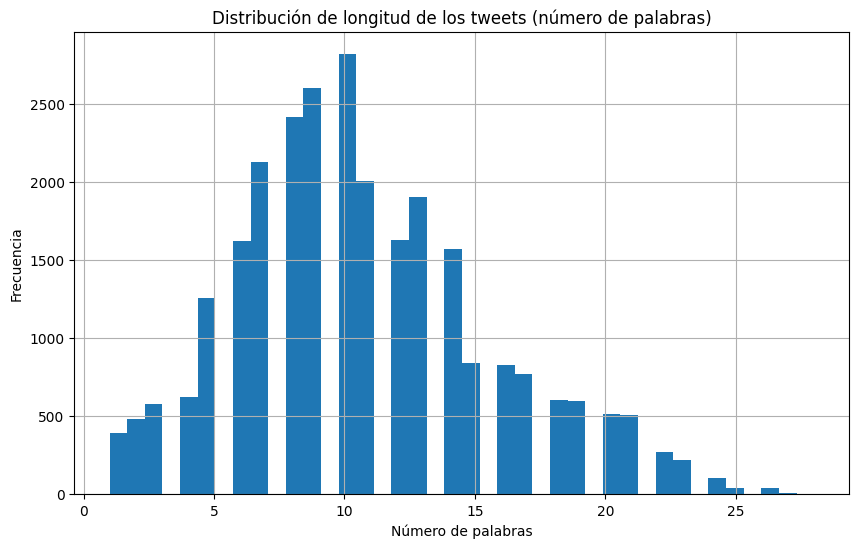

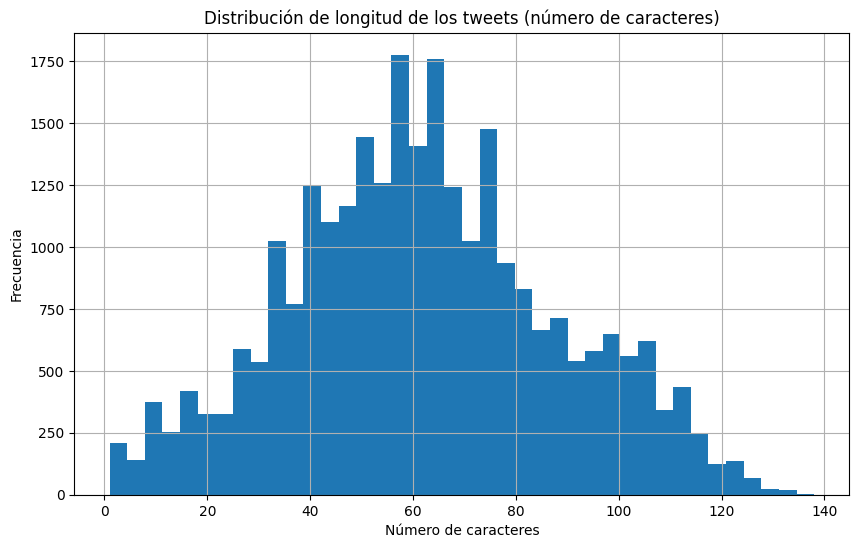


## Extensión del vector de stopwords
Se parte del conjunto estándar de stopwords en inglés y luego se agregan palabras frecuentes del dominio financiero. Esto es importante porque términos como *market*, *stock* o *price* aparecen repetidamente en este tipo de textos, pero no siempre ayudan a distinguir los temas principales del corpus.


Cantidad de stopwords base en inglés: 198
Cantidad de stopwords personalizadas agregadas: 24
Tamaño final del vector extendido de stopwords: 222


## Procesamiento básico de textos

100%|██████████| 27363/27363 [00:03<00:00, 7565.33it/s]

Ejemplo de procesamiento:


...

## Frecuencias de palabras más comunes

Top 20 palabras más comunes del corpus:


,palabra,frecuencia
0,rt,4591
1,inc,3877
2,amp,2953
3,earnings,1854
4,analysts,1628
5,eps,1320
6,buy,1103
7,binance,1071
8,expected,1062
9,short,1048


Top 20 stems más comunes del corpus:


,stem,frecuencia
0,rt,4591
1,inc,3879
2,amp,2953
3,earn,2002
4,analyst,1811
5,expect,1403
6,ep,1329
7,group,1308
8,hold,1296
9,option,1292


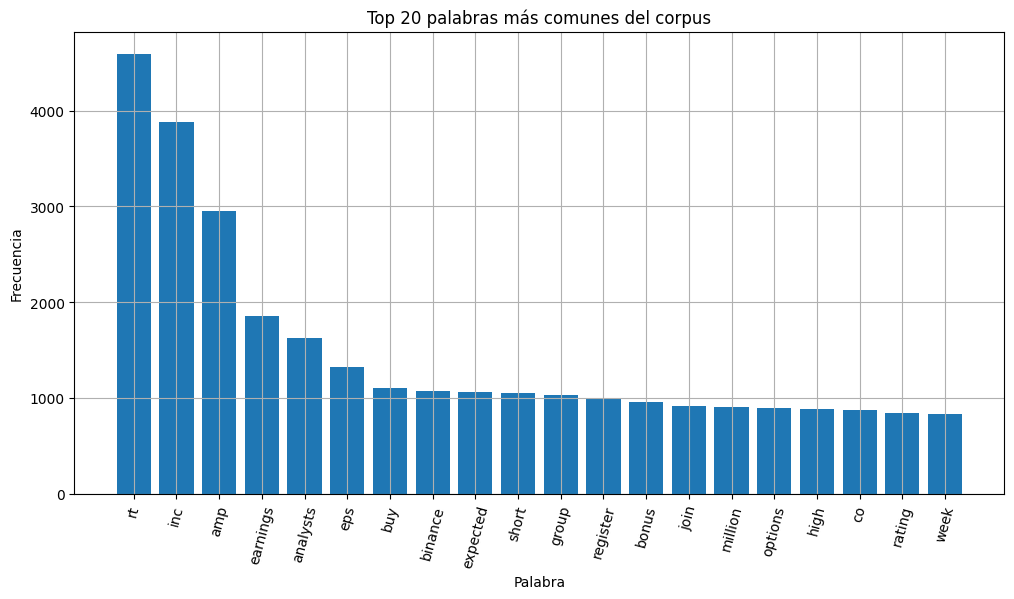

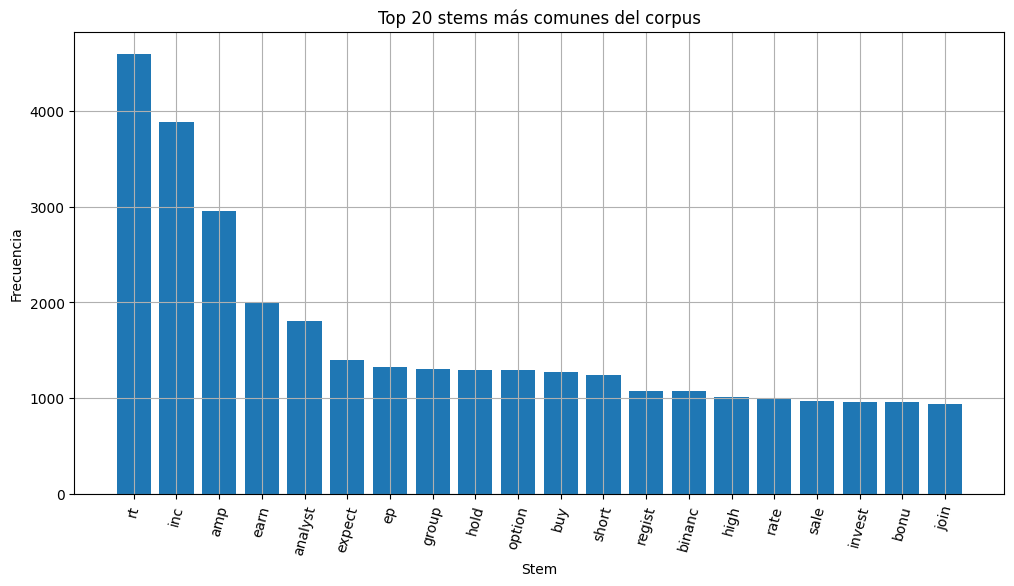

## WordCloud

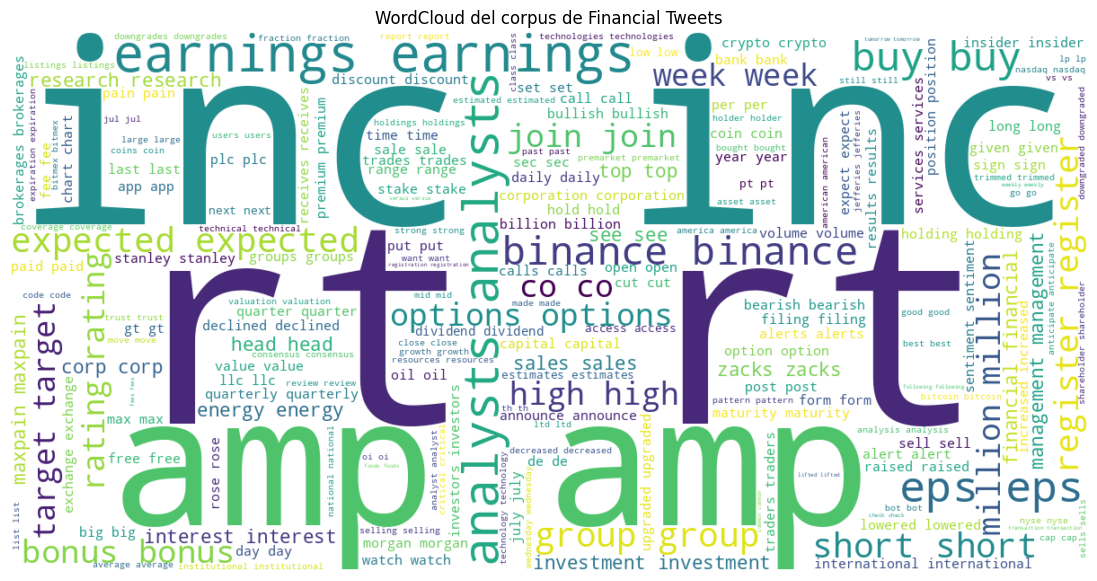


## Análisis de sentimientos
Para esta parte se utiliza **VADER**, una herramienta de NLTK adecuada para textos cortos y lenguaje tipo redes sociales. Se obtiene un puntaje de polaridad para cada tweet y, a partir de él, se clasifica cada texto como positivo, neutral o negativo.


100%|██████████| 27363/27363 [00:04<00:00, 6414.67it/s]


Distribución de sentimientos:


,count
sentiment,
neutral,13536
positivo,10414
negativo,3413


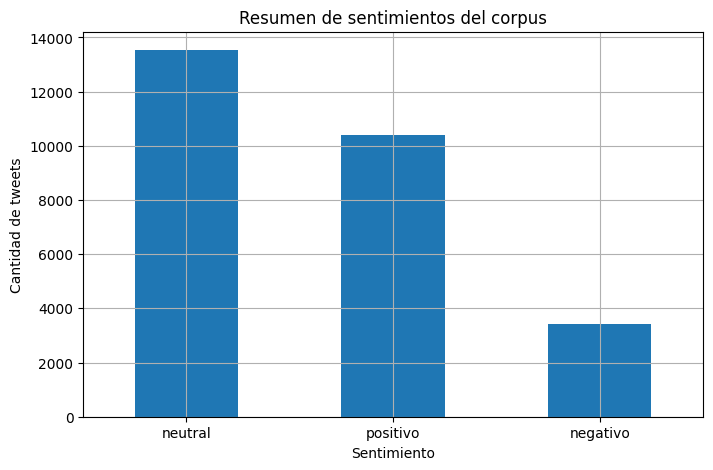

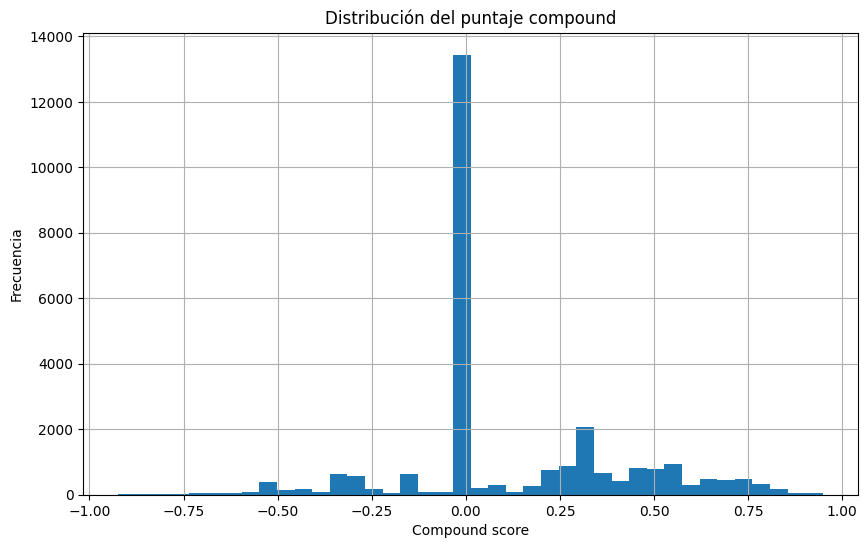

## Análisis complementario por fuente

Fuentes con mayor sentimiento promedio positivo:


,compound
source_name,
magillin3,0.9485
Ashikeqbal21,0.9432
billho888,0.9423
juliaalexa___,0.9423
LEXUSLAW,0.9359
janopetsa,0.9311
rahulrumalla,0.9299
mrzoriley,0.9274
Stock__Master,0.9241


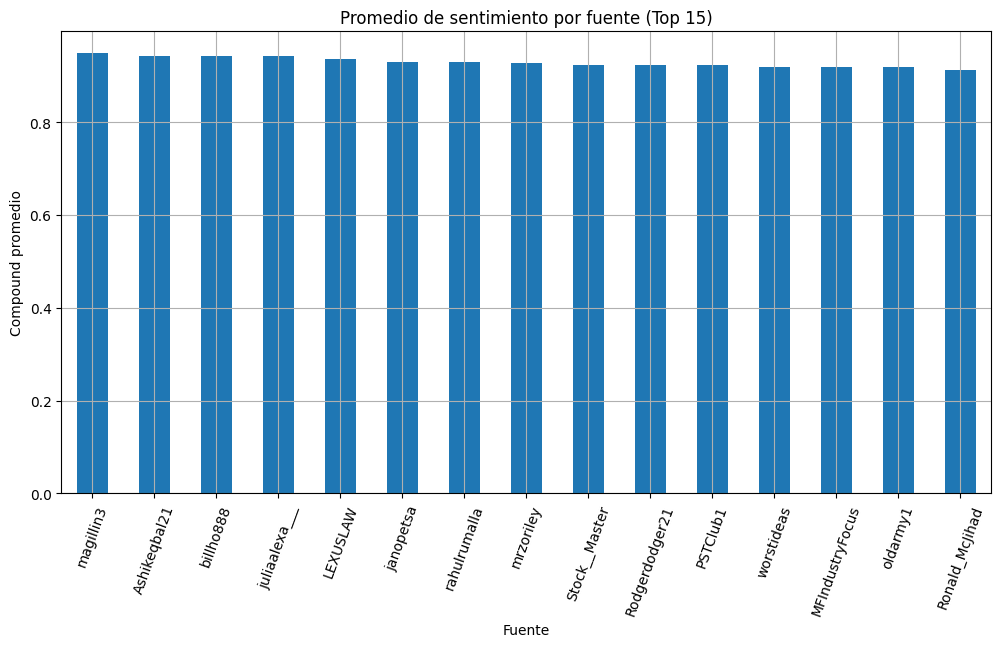


## Visualización con t-SNE
Los textos se convierten a una representación numérica usando TF-IDF y después se aplica t-SNE para reducir la dimensionalidad y visualizar posibles agrupamientos entre tweets.


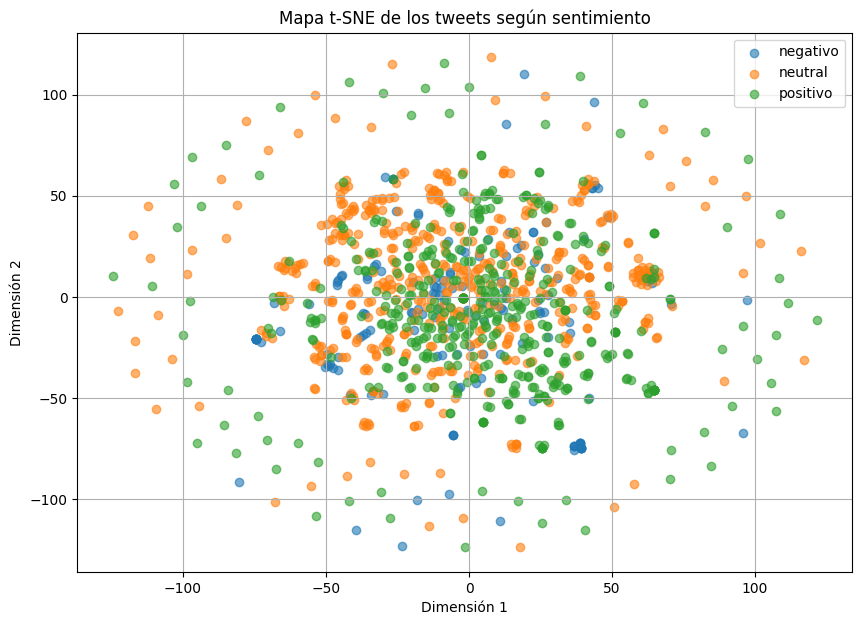

## Corpus final procesado

Vista del corpus final procesado:


,dataset,source_name,original_text,clean_text,num_chars,num_words,tokens_no_stop,stems,compound,sentiment
0,financial_tweets,GoldmanSachs,VIDEO: “I was in my office. I was minding my own business...” –David Solomon tells $GS interns how he learned he wa…...,video i was in my office i was minding my own business david solomon tells interns how he learned he wa,103,21,"[video, office, minding, business, david, solomon, tells, interns, learned, wa]","[video, offic, mind, busi, david, solomon, tell, intern, learn, wa]",0.0000,neutral
1,financial_tweets,StockTwits,The price of lumber $LB_F is down 22% since hitting its YTD highs. The Macy's $M turnaround is still happening.… htt...,the price of lumber is down since hitting its ytd highs the macy s turnaround is still happening,96,18,"[lumber, since, hitting, ytd, highs, macy, turnaround, still, happening]","[lumber, sinc, hit, ytd, high, maci, turnaround, still, happen]",0.0000,neutral
2,financial_tweets,TheStreet,Who says the American Dream is dead? https://t.co/CRgx19x7sA,who says the american dream is dead,35,7,"[says, american, dream, dead]","[say, american, dream, dead]",-0.5106,negativo
3,financial_tweets,MarketWatch,Barry Silbert is extremely optimistic on bitcoin -- but predicts that 99% of new crypto entrants are “going to zero…...,barry silbert is extremely optimistic on bitcoin but predicts that of new crypto entrants are going to zero,107,18,"[barry, silbert, extremely, optimistic, bitcoin, predicts, crypto, entrants, going, zero]","[barri, silbert, extrem, optimist, bitcoin, predict, crypto, entrant, go, zero]",0.2014,positivo
4,financial_tweets,Forbes,How satellites avoid attacks and space junk while circling the Earth https://t.co/aHzIV3Lqp5 #paid @Oracle https://t...,how satellites avoid attacks and space junk while circling the earth paid,73,12,"[satellites, avoid, attacks, space, junk, circling, earth, paid]","[satellit, avoid, attack, space, junk, circl, earth, paid]",-0.6249,negativo


Dimensiones del corpus final:
(27363, 10)


## Interpretación de resultados


A partir del análisis realizado, se observa que el corpus construido sí permite identificar patrones relevantes en los textos.

1) Construcción del corpus
Se construyó un corpus a partir del dataset Financial Tweets. Después de limpiar los textos y eliminar registros vacíos, el corpus final quedó conformado por 27,363 tweets útiles.

2) Longitud de los textos
En promedio, los tweets contienen 10.73 palabras y 62.09 caracteres. La mediana de palabras fue de 10.00. Esto confirma que se trata de textos breves, algo esperado por la naturaleza del formato Twitter.

3) Frecuencias de palabras
Después de aplicar limpieza, tokenización y remoción de stopwords, las palabras más comunes fueron: rt (4591), inc (3877), amp (2953), earnings (1854), analysts (1628). Estas frecuencias ayudan a identificar los temas dominantes dentro del corpus.

4) Extensión del vector de stopwords
Se partió de un conjunto base de stopwords en inglés y se amplió con términos del dominio financiero. Esto permitió red


## Conclusión
A partir del desarrollo de este proyecto fue posible construir un corpus funcional y aplicar sobre él un flujo completo de procesamiento básico de textos. La preparación de los datos permitió pasar de un conjunto de registros sin estructura analítica directa a una representación más limpia, comparable y útil para su exploración.

Las operaciones de tokenización, stemming y remoción de stopwords hicieron posible reducir ruido y conservar los elementos más informativos del lenguaje. Esto se reflejó en las frecuencias de palabras, en la claridad de las visualizaciones y en la capacidad de distinguir patrones relevantes dentro del corpus.

Por su parte, el análisis de sentimientos permitió identificar la polaridad general de los textos y resumirla de manera cuantitativa y visual. En conclusión, el proyecto cumple con los requerimientos solicitados y demuestra el valor del procesamiento de lenguaje natural para analizar información textual del ámbito financiero.



Archivos generados correctamente:
 - corpus_financial_tweets_procesado.csv
 - frecuencias_palabras_financial_top100.csv


In [ ]:
# ==============================================================
# PROCESAMIENTO DE TEXTOS Y ANÁLISIS DE SENTIMIENTOS
# DATASET ELEGIDO: FINANCIAL TWEETS
# VERSIÓN FINAL ROBUSTA Y MUY COMENTADA
# ==============================================================

# --------------------------------------------------------------
# BLOQUE 1. INSTALACIÓN DE LIBRERÍAS
# --------------------------------------------------------------
# En este bloque se instalan las librerías necesarias para ejecutar
# el proyecto en Google Colab.
#
# Se usan:
# - nltk: para procesamiento de lenguaje natural
# - wordcloud: para generar la nube de palabras
# - scikit-learn: para TF-IDF y t-SNE
# - tqdm: para mostrar barras de progreso
# --------------------------------------------------------------
!pip install -q nltk wordcloud scikit-learn tqdm


# --------------------------------------------------------------
# BLOQUE 2. IMPORTACIÓN DE LIBRERÍAS
# --------------------------------------------------------------
# Aquí se importan todas las librerías que se ocuparán a lo largo
# del proyecto.
#
# También se desactivan warnings para que la salida sea más limpia.
# --------------------------------------------------------------
import os
import re
import csv
import warnings
warnings.filterwarnings("ignore")

# Librerías para manejo numérico y tabular
import numpy as np
import pandas as pd

# Librería para gráficas
import matplotlib.pyplot as plt

# Counter sirve para contar frecuencias de palabras
from collections import Counter

# tqdm permite ver el avance de ciertos procesos largos
from tqdm import tqdm

# Librería para la nube de palabras
from wordcloud import WordCloud

# Librerías de NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer

# Librerías de scikit-learn para vectorización y reducción de dimensión
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# files permite subir archivos manualmente en Colab
from google.colab import files

# Markdown y display permiten mostrar texto bonito tipo reporte
from IPython.display import display, Markdown


# --------------------------------------------------------------
# BLOQUE 3. DESCARGAS DE RECURSOS DE NLTK
# --------------------------------------------------------------
# NLTK necesita descargar algunos recursos antes de usarlos.
#
# - punkt: tokenización
# - punkt_tab: algunas versiones de Colab lo requieren
# - stopwords: lista de stopwords en inglés
# - vader_lexicon: recurso para análisis de sentimientos con VADER
# --------------------------------------------------------------
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("vader_lexicon")


# --------------------------------------------------------------
# BLOQUE 4. CONFIGURACIÓN VISUAL
# --------------------------------------------------------------
# Se ajustan algunos parámetros para que:
# - las gráficas salgan con mejor tamaño
# - las tablas se vean más completas
# - los textos de pandas no se corten tan rápido
# --------------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)


# --------------------------------------------------------------
# BLOQUE 5. FUNCIONES AUXILIARES
# --------------------------------------------------------------
# En esta sección se definen funciones que se van a reutilizar
# varias veces en el proyecto.
# --------------------------------------------------------------

def robust_read_csv(filepath):
    """
    Esta función intenta leer un CSV usando varias configuraciones
    distintas para evitar errores cuando el archivo tiene:
    - filas mal formadas
    - diferente codificación
    - separadores problemáticos
    - comillas inconsistentes

    Se usa on_bad_lines='skip' para saltar filas problemáticas
    en lugar de romper toda la lectura del archivo.
    """
    attempts = [
        {"sep": ",", "engine": "python", "on_bad_lines": "skip", "encoding": "utf-8"},
        {"sep": ",", "engine": "python", "on_bad_lines": "skip", "encoding": "latin-1"},
        {"sep": ",", "engine": "python", "on_bad_lines": "skip", "encoding": "utf-8", "quoting": csv.QUOTE_MINIMAL},
        {"sep": ",", "engine": "python", "on_bad_lines": "skip", "encoding": "latin-1", "quoting": csv.QUOTE_MINIMAL},
        {"sep": None, "engine": "python", "on_bad_lines": "skip", "encoding": "utf-8"},
        {"sep": None, "engine": "python", "on_bad_lines": "skip", "encoding": "latin-1"},
    ]

    last_error = None

    # Se prueba cada configuración hasta que alguna funcione
    for i, params in enumerate(attempts, 1):
        try:
            df = pd.read_csv(filepath, **params)
            print(f"Lectura exitosa con intento {i}: {params}")
            return df
        except Exception as e:
            last_error = e
            print(f"Intento {i} falló.")

    # Si ninguna opción sirve, se lanza el último error encontrado
    raise last_error


def find_text_column(df):
    """
    Esta función intenta detectar automáticamente la columna que
    contiene el texto principal del dataset.

    Primero busca nombres típicos como:
    text, tweet, content, message

    Si no encuentra nada, revisa las columnas tipo texto (object)
    y escoge la que en promedio tenga textos más largos.
    """
    possible_cols = ["text", "Text", "tweet", "Tweet", "content", "message"]

    for col in possible_cols:
        if col in df.columns:
            return col

    object_cols = df.select_dtypes(include="object").columns.tolist()

    if len(object_cols) > 0:
        avg_lengths = {}
        for col in object_cols:
            try:
                avg_lengths[col] = df[col].astype(str).str.len().mean()
            except:
                pass

        if len(avg_lengths) > 0:
            return max(avg_lengths, key=avg_lengths.get)

    return None


def find_source_column(df):
    """
    Esta función intenta detectar una columna que represente
    la fuente del tweet, por ejemplo:
    source, user, username, account
    """
    possible_cols = ["source", "Source", "user", "username", "account"]

    for col in possible_cols:
        if col in df.columns:
            return col

    return None


def clean_text_basic(text):
    """
    Esta función aplica una limpieza básica al texto.

    Proceso:
    1. Convierte a minúsculas
    2. Elimina enlaces
    3. Elimina menciones tipo @usuario
    4. Elimina el símbolo # pero deja la palabra
    5. Elimina tickers bursátiles como $AAPL
    6. Elimina caracteres especiales
    7. Elimina espacios repetidos
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\$[A-Za-z_\.]+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize_text(text):
    """
    Esta función tokeniza el texto.

    Primero intenta usar word_tokenize de NLTK.
    Si por alguna razón falla, usa una expresión regular
    como método de respaldo.

    Esto hace el código más robusto.
    """
    try:
        return word_tokenize(text)
    except:
        return re.findall(r"[a-zA-Z]+", str(text).lower())


def remove_stopwords(tokens, stop_words):
    """
    Esta función recibe una lista de tokens y elimina:
    - palabras que estén en la lista de stopwords
    - tokens de longitud 1 o menores
    """
    return [tok for tok in tokens if tok not in stop_words and len(tok) > 1]


def apply_stemming(tokens, stemmer):
    """
    Esta función aplica stemming a cada token.

    El stemming reduce palabras a una raíz aproximada.
    Ejemplo:
    investing -> invest
    markets -> market
    """
    return [stemmer.stem(tok) for tok in tokens]


def sentiment_category(score):
    """
    Esta función convierte el score compound de VADER
    en una categoría de sentimiento.

    Reglas:
    - >= 0.05  -> positivo
    - <= -0.05 -> negativo
    - otro caso -> neutral
    """
    if score >= 0.05:
        return "positivo"
    elif score <= -0.05:
        return "negativo"
    else:
        return "neutral"


def tsne_plot_from_texts(texts, labels=None, sample_size=1200, title="Mapa t-SNE de los textos"):
    """
    Esta función construye una visualización t-SNE.

    Flujo:
    1. Filtra textos vacíos
    2. Si hay demasiados textos, toma una muestra
    3. Convierte textos a vectores TF-IDF
    4. Aplica t-SNE para reducir a 2 dimensiones
    5. Grafica el resultado

    sample_size se limita para que Colab no se vuelva muy lento.
    """
    texts = [str(t) for t in texts if str(t).strip() != ""]

    if len(texts) == 0:
        print("No hay textos suficientes para t-SNE.")
        return

    if len(texts) > sample_size:
        idx = np.random.choice(len(texts), sample_size, replace=False)
        sampled_texts = [texts[i] for i in idx]
        sampled_labels = [labels[i] for i in idx] if labels is not None else None
    else:
        sampled_texts = texts
        sampled_labels = labels

    # TF-IDF transforma los textos en vectores numéricos
    vectorizer = TfidfVectorizer(max_features=400, stop_words="english")
    X = vectorizer.fit_transform(sampled_texts).toarray()

    # Se ajusta perplexity dinámicamente para evitar errores
    perplexity_value = min(30, max(5, len(sampled_texts) // 20))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity_value,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    X_embedded = tsne.fit_transform(X)

    plt.figure(figsize=(10, 7))

    # Si hay etiquetas, se colorea por categoría
    if sampled_labels is not None:
        sampled_labels = np.array(sampled_labels)
        unique_labels = sorted(list(set(sampled_labels)))

        for lab in unique_labels:
            mask = sampled_labels == lab
            plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], alpha=0.6, label=lab)

        plt.legend()
    else:
        plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.6)

    plt.title(title)
    plt.xlabel("Dimensión 1")
    plt.ylabel("Dimensión 2")
    plt.show()


# --------------------------------------------------------------
# BLOQUE 6. ENCABEZADO TIPO REPORTE
# --------------------------------------------------------------
# Esta parte imprime el contenido tipo entrega/reporte
# para que el notebook se vea más presentable.
# --------------------------------------------------------------
display(Markdown("# Proyecto de análisis de sentimientos y procesamiento de textos"))
display(Markdown("## Dataset elegido: Financial Tweets"))
display(Markdown("**Nombre sugerido del archivo:** `DS_C6_SC5_NOMBRE.ipynb`"))

display(Markdown("""
### Justificación del dataset elegido
En este proyecto se eligió trabajar únicamente con el dataset **Financial Tweets**, ya que la consigna indica seleccionar solo uno de los datasets propuestos. Este conjunto de datos resulta adecuado porque contiene textos breves del contexto financiero, lo que permite aplicar limpieza, tokenización, stemming, remoción de stopwords y análisis de sentimientos sobre publicaciones reales relacionadas con mercados, empresas, noticias económicas e influencers financieros.

Además, al tratarse de tweets, el proyecto permite trabajar con elementos característicos de redes sociales como menciones, hashtags, enlaces y tickers bursátiles, lo cual hace más completo el proceso de limpieza y construcción del corpus.
"""))

display(Markdown("""
## Introducción
En este proyecto se desarrolla un análisis de procesamiento de lenguaje natural sobre un corpus de textos construido a partir del dataset **Financial Tweets**. El propósito principal es aplicar técnicas básicas de limpieza y transformación de texto para explorar la información contenida en los documentos y posteriormente realizar un análisis de sentimientos.
"""))

display(Markdown("""
## Objetivo general
Construir un corpus de textos a partir del dataset seleccionado y aplicar técnicas básicas de procesamiento de lenguaje natural para explorar su contenido, calcular frecuencias relevantes y realizar un análisis de sentimientos apoyado en representaciones visuales.
"""))

display(Markdown("""
## Objetivos específicos
- Cargar todos los registros del dataset en un DataFrame para facilitar su manipulación y análisis.
- Construir un corpus de textos a partir de la información disponible en el archivo seleccionado.
- Calcular frecuencias de longitud de texto, frecuencias de palabras más comunes y extensión del vector de stopwords.
- Aplicar operaciones básicas de procesamiento de texto como tokenización, remoción de stopwords y stemming.
- Generar gráficas que permitan explorar la estructura y contenido del corpus.
- Implementar análisis de sentimientos para identificar la polaridad de los textos.
- Interpretar los resultados obtenidos para extraer información relevante del conjunto de datos.
"""))

display(Markdown("""
## Metodología
La metodología seguida en este proyecto se dividió en varias etapas:

**1. Carga de datos:** se cargan los archivos `.csv` del dataset en Google Colab y se almacenan en un DataFrame de pandas.

**2. Construcción del corpus:** se selecciona la columna principal de texto y se eliminan registros nulos o vacíos.

**3. Limpieza y preprocesamiento:** se convierten los textos a minúsculas, se eliminan enlaces, menciones, hashtags, símbolos bursátiles y caracteres especiales. Después se aplican tokenización, remoción de stopwords y stemming.

**4. Exploración del corpus:** se calculan longitudes de texto, palabras más comunes, stems más frecuentes y tamaño del vector extendido de stopwords.

**5. Análisis de sentimientos:** se utiliza VADER para clasificar los textos como positivos, negativos o neutrales.

**6. Visualización:** se construyen histogramas, gráficas de frecuencia, WordCloud y una representación t-SNE.
"""))


# --------------------------------------------------------------
# BLOQUE 7. CARGA DE ARCHIVOS
# --------------------------------------------------------------
# Aquí el usuario sube manualmente los archivos.
# Para este proyecto solo se ocupan los del dataset Financial Tweets.
# --------------------------------------------------------------
display(Markdown("## Carga de archivos"))

print("Sube los archivos del dataset Financial Tweets:")
print(" - stockerbot-export.csv")
print(" - stocks_cleaned.csv")

uploaded = files.upload()

print("\nArchivos cargados:")
for file_name in uploaded.keys():
    print(" -", file_name)


# --------------------------------------------------------------
# BLOQUE 8. LOCALIZAR Y LEER LOS ARCHIVOS
# --------------------------------------------------------------
# Se buscan automáticamente los archivos cargados.
# --------------------------------------------------------------
tweets_file = None
stocks_file = None

for f in os.listdir():
    lower_f = f.lower()

    if "stockerbot-export" in lower_f and lower_f.endswith(".csv"):
        tweets_file = f

    if "stocks_cleaned" in lower_f and lower_f.endswith(".csv"):
        stocks_file = f

# Si no se encuentra el archivo principal, se detiene la ejecución
if tweets_file is None:
    raise FileNotFoundError("No se encontró el archivo stockerbot-export.csv")

# Se lee el archivo principal usando la función robusta
df_raw = robust_read_csv(tweets_file)
print(f"\nArchivo principal cargado correctamente: {tweets_file}")

# El archivo auxiliar se intenta leer, pero si falla no rompe el proyecto
if stocks_file is not None:
    try:
        stocks_aux = robust_read_csv(stocks_file)
        print(f"Archivo auxiliar cargado correctamente: {stocks_file}")
    except Exception as e:
        stocks_aux = None
        print(f"No se pudo leer {stocks_file}, pero se continuará. Error: {e}")
else:
    stocks_aux = None
    print("No se encontró stocks_cleaned.csv. Se continuará solo con stockerbot-export.csv.")


# --------------------------------------------------------------
# BLOQUE 9. EXPLORACIÓN INICIAL
# --------------------------------------------------------------
# Se revisa:
# - tamaño del DataFrame
# - nombres de columnas
# - primeras filas
# Esto sirve para validar que sí se cargó correctamente.
# --------------------------------------------------------------
display(Markdown("## Exploración inicial del dataset"))

print("\nDimensiones del DataFrame principal:")
print(df_raw.shape)

print("\nColumnas disponibles en el archivo principal:")
print(df_raw.columns.tolist())

print("\nPrimeros registros del DataFrame principal:")
display(df_raw.head())

if stocks_aux is not None:
    print("\nDimensiones del archivo auxiliar:")
    print(stocks_aux.shape)

    print("\nColumnas disponibles en el archivo auxiliar:")
    print(stocks_aux.columns.tolist())

    print("\nPrimeros registros del archivo auxiliar:")
    display(stocks_aux.head())


# --------------------------------------------------------------
# BLOQUE 10. DETECCIÓN DE COLUMNAS IMPORTANTES
# --------------------------------------------------------------
# Aquí se detecta automáticamente:
# - la columna con texto
# - la columna con la fuente
# --------------------------------------------------------------
text_col = find_text_column(df_raw)
source_col = find_source_column(df_raw)

if text_col is None:
    raise ValueError("No se pudo detectar automáticamente la columna de texto.")

print(f"\nColumna de texto detectada: {text_col}")
print(f"Columna de fuente detectada: {source_col if source_col is not None else 'No encontrada'}")


# --------------------------------------------------------------
# BLOQUE 11. CONSTRUCCIÓN DEL CORPUS
# --------------------------------------------------------------
# Se crea un DataFrame base con:
# - nombre del dataset
# - fuente
# - texto original
# --------------------------------------------------------------
display(Markdown("## Construcción del corpus"))

df = df_raw.copy()
df["dataset"] = "financial_tweets"
df["source_name"] = df[source_col].astype(str) if source_col is not None else "desconocido"
df["original_text"] = df[text_col].astype(str)

print("Vista inicial del corpus:")
display(df[["dataset", "source_name", "original_text"]].head())


# --------------------------------------------------------------
# BLOQUE 12. LIMPIEZA DEL TEXTO
# --------------------------------------------------------------
# Aquí se eliminan:
# - nulos
# - cadenas vacías
# - texto basura después de la limpieza
# --------------------------------------------------------------
display(Markdown("""
## Limpieza del texto
El texto de Twitter contiene elementos que pueden introducir ruido, como enlaces, menciones, hashtags, símbolos bursátiles y caracteres especiales. Por ello se realiza una limpieza básica para conservar únicamente el contenido más útil para el análisis textual.
"""))

df = df[df["original_text"].notna()].copy()
df["original_text"] = df["original_text"].astype(str).str.strip()
df = df[df["original_text"] != ""].copy()

df["clean_text"] = df["original_text"].apply(clean_text_basic)
df = df[df["clean_text"].str.strip() != ""].copy()

print("Dimensiones después de la limpieza:")
print(df.shape)

display(df[["original_text", "clean_text"]].head(10))


# --------------------------------------------------------------
# BLOQUE 13. FRECUENCIAS DE LONGITUDES DE TEXTO
# --------------------------------------------------------------
# Se calcula:
# - número de caracteres
# - número de palabras
# Esto cumple con una parte de la consigna.
# --------------------------------------------------------------
display(Markdown("## Frecuencias de longitudes de texto"))

df["num_chars"] = df["clean_text"].apply(len)
df["num_words"] = df["clean_text"].apply(lambda x: len(x.split()))

print("Resumen descriptivo de las longitudes del texto:")
display(df[["num_chars", "num_words"]].describe())

plt.figure(figsize=(10, 6))
plt.hist(df["num_words"], bins=40)
plt.title("Distribución de longitud de los tweets (número de palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["num_chars"], bins=40)
plt.title("Distribución de longitud de los tweets (número de caracteres)")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()


# --------------------------------------------------------------
# BLOQUE 14. EXTENSIÓN DEL VECTOR DE STOPWORDS
# --------------------------------------------------------------
# Se toman stopwords estándar en inglés y se agregan algunas
# del dominio financiero que aparecen con mucha frecuencia.
# --------------------------------------------------------------
display(Markdown("""
## Extensión del vector de stopwords
Se parte del conjunto estándar de stopwords en inglés y luego se agregan palabras frecuentes del dominio financiero. Esto es importante porque términos como *market*, *stock* o *price* aparecen repetidamente en este tipo de textos, pero no siempre ayudan a distinguir los temas principales del corpus.
"""))

english_stopwords = set(stopwords.words("english"))

financial_custom_stopwords = {
    "market", "markets", "stock", "stocks", "company", "companies",
    "share", "shares", "price", "prices", "trading", "trade",
    "today", "via", "news", "said", "say", "one", "new",
    "us", "u", "s", "would", "could", "also"
}

extended_stopwords = english_stopwords.union(financial_custom_stopwords)

print("Cantidad de stopwords base en inglés:", len(english_stopwords))
print("Cantidad de stopwords personalizadas agregadas:", len(extended_stopwords) - len(english_stopwords))
print("Tamaño final del vector extendido de stopwords:", len(extended_stopwords))


# --------------------------------------------------------------
# BLOQUE 15. PROCESAMIENTO BÁSICO DEL TEXTO
# --------------------------------------------------------------
# Aquí se hace:
# - tokenización
# - remoción de stopwords
# - stemming
# --------------------------------------------------------------
display(Markdown("## Procesamiento básico de textos"))

stemmer = PorterStemmer()
tqdm.pandas()

df["tokens"] = df["clean_text"].progress_apply(tokenize_text)
df["tokens_no_stop"] = df["tokens"].progress_apply(lambda toks: remove_stopwords(toks, extended_stopwords))
df["stems"] = df["tokens_no_stop"].progress_apply(lambda toks: apply_stemming(toks, stemmer))

print("Ejemplo de procesamiento:")
display(df[["clean_text", "tokens", "tokens_no_stop", "stems"]].head(5))


# --------------------------------------------------------------
# BLOQUE 16. FRECUENCIA DE PALABRAS MÁS COMUNES
# --------------------------------------------------------------
# Se cuentan las palabras más repetidas del corpus ya limpio.
# --------------------------------------------------------------
display(Markdown("## Frecuencias de palabras más comunes"))

all_tokens = [tok for row in df["tokens_no_stop"] for tok in row]
all_stems = [stem for row in df["stems"] for stem in row]

token_counter = Counter(all_tokens)
stem_counter = Counter(all_stems)

top_words_df = pd.DataFrame(token_counter.most_common(20), columns=["palabra", "frecuencia"])
top_stems_df = pd.DataFrame(stem_counter.most_common(20), columns=["stem", "frecuencia"])

print("Top 20 palabras más comunes del corpus:")
display(top_words_df)

print("Top 20 stems más comunes del corpus:")
display(top_stems_df)

plt.figure(figsize=(12, 6))
plt.bar(top_words_df["palabra"], top_words_df["frecuencia"])
plt.title("Top 20 palabras más comunes del corpus")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.xticks(rotation=75)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(top_stems_df["stem"], top_stems_df["frecuencia"])
plt.title("Top 20 stems más comunes del corpus")
plt.xlabel("Stem")
plt.ylabel("Frecuencia")
plt.xticks(rotation=75)
plt.show()


# --------------------------------------------------------------
# BLOQUE 17. WORDCLOUD
# --------------------------------------------------------------
# Se genera una nube de palabras con los tokens ya limpios.
# --------------------------------------------------------------
display(Markdown("## WordCloud"))

text_for_cloud = " ".join([((word + " ") * freq) for word, freq in token_counter.items()])

if len(text_for_cloud.strip()) > 0:
    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=200
    ).generate(text_for_cloud)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud del corpus de Financial Tweets")
    plt.show()
else:
    print("No fue posible generar la nube de palabras porque no hay tokens suficientes.")


# --------------------------------------------------------------
# BLOQUE 18. ANÁLISIS DE SENTIMIENTOS
# --------------------------------------------------------------
# Se usa VADER para calcular un score compound y clasificar
# cada tweet como positivo, negativo o neutral.
# --------------------------------------------------------------
display(Markdown("""
## Análisis de sentimientos
Para esta parte se utiliza **VADER**, una herramienta de NLTK adecuada para textos cortos y lenguaje tipo redes sociales. Se obtiene un puntaje de polaridad para cada tweet y, a partir de él, se clasifica cada texto como positivo, neutral o negativo.
"""))

sia = SentimentIntensityAnalyzer()

df["sentiment_scores"] = df["clean_text"].progress_apply(lambda x: sia.polarity_scores(x))
df["compound"] = df["sentiment_scores"].apply(lambda d: d["compound"])
df["sentiment"] = df["compound"].apply(sentiment_category)

print("Distribución de sentimientos:")
sent_counts = df["sentiment"].value_counts()
display(sent_counts)

plt.figure(figsize=(8, 5))
sent_counts.plot(kind="bar")
plt.title("Resumen de sentimientos del corpus")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de tweets")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["compound"], bins=40)
plt.title("Distribución del puntaje compound")
plt.xlabel("Compound score")
plt.ylabel("Frecuencia")
plt.show()


# --------------------------------------------------------------
# BLOQUE 19. ANÁLISIS COMPLEMENTARIO POR FUENTE
# --------------------------------------------------------------
# Se calcula sentimiento promedio por fuente para enriquecer
# un poco más el análisis.
# --------------------------------------------------------------
display(Markdown("## Análisis complementario por fuente"))

if "source_name" in df.columns:
    source_sentiment = (
        df.groupby("source_name")["compound"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    print("Fuentes con mayor sentimiento promedio positivo:")
    display(source_sentiment)

    plt.figure(figsize=(12, 6))
    source_sentiment.plot(kind="bar")
    plt.title("Promedio de sentimiento por fuente (Top 15)")
    plt.xlabel("Fuente")
    plt.ylabel("Compound promedio")
    plt.xticks(rotation=70)
    plt.show()


# --------------------------------------------------------------
# BLOQUE 20. VISUALIZACIÓN CON t-SNE
# --------------------------------------------------------------
# Se hace reducción de dimensionalidad para visualizar
# agrupamientos entre textos.
# --------------------------------------------------------------
display(Markdown("""
## Visualización con t-SNE
Los textos se convierten a una representación numérica usando TF-IDF y después se aplica t-SNE para reducir la dimensionalidad y visualizar posibles agrupamientos entre tweets.
"""))

try:
    tsne_plot_from_texts(
        texts=df["clean_text"].tolist(),
        labels=df["sentiment"].tolist(),
        sample_size=1200,
        title="Mapa t-SNE de los tweets según sentimiento"
    )
except Exception as e:
    print(f"No se pudo generar t-SNE, pero el resto del análisis sí se completó. Error: {e}")


# --------------------------------------------------------------
# BLOQUE 21. CORPUS FINAL PROCESADO
# --------------------------------------------------------------
# Aquí se arma una tabla final con las columnas más importantes.
# --------------------------------------------------------------
display(Markdown("## Corpus final procesado"))

final_columns = [
    "dataset",
    "source_name",
    "original_text",
    "clean_text",
    "num_chars",
    "num_words",
    "tokens_no_stop",
    "stems",
    "compound",
    "sentiment"
]

corpus_df = df[final_columns].copy()

print("Vista del corpus final procesado:")
display(corpus_df.head())

print("Dimensiones del corpus final:")
print(corpus_df.shape)


# --------------------------------------------------------------
# BLOQUE 22. INTERPRETACIÓN DE RESULTADOS
# --------------------------------------------------------------
# Se imprime una interpretación automática de los resultados
# para que te sirva como base del reporte.
# --------------------------------------------------------------
display(Markdown("## Interpretación de resultados"))

avg_words = df["num_words"].mean()
median_words = df["num_words"].median()
avg_chars = df["num_chars"].mean()

top5_words = token_counter.most_common(5)
top5_words_str = ", ".join([f"{w} ({f})" for w, f in top5_words])

positive_pct = (df["sentiment"] == "positivo").mean() * 100
neutral_pct = (df["sentiment"] == "neutral").mean() * 100
negative_pct = (df["sentiment"] == "negativo").mean() * 100

print(f"""
A partir del análisis realizado, se observa que el corpus construido sí permite identificar patrones relevantes en los textos.

1) Construcción del corpus
Se construyó un corpus a partir del dataset Financial Tweets. Después de limpiar los textos y eliminar registros vacíos, el corpus final quedó conformado por {len(df):,} tweets útiles.

2) Longitud de los textos
En promedio, los tweets contienen {avg_words:.2f} palabras y {avg_chars:.2f} caracteres. La mediana de palabras fue de {median_words:.2f}. Esto confirma que se trata de textos breves, algo esperado por la naturaleza del formato Twitter.

3) Frecuencias de palabras
Después de aplicar limpieza, tokenización y remoción de stopwords, las palabras más comunes fueron: {top5_words_str}. Estas frecuencias ayudan a identificar los temas dominantes dentro del corpus.

4) Extensión del vector de stopwords
Se partió de un conjunto base de stopwords en inglés y se amplió con términos del dominio financiero. Esto permitió reducir el peso de palabras demasiado repetidas como stock, market o price, lo que mejoró la visibilidad de términos más informativos.

5) Análisis de sentimientos
La distribución general de sentimientos fue:
- Positivos: {positive_pct:.2f}%
- Neutrales: {neutral_pct:.2f}%
- Negativos: {negative_pct:.2f}%

En conjunto, el análisis muestra que los tweets financieros sí pueden transformarse en un corpus útil para exploración textual y análisis de sentimientos.
""")


# --------------------------------------------------------------
# BLOQUE 23. CONCLUSIÓN
# --------------------------------------------------------------
# Se imprime una conclusión final del proyecto.
# --------------------------------------------------------------
display(Markdown("""
## Conclusión
A partir del desarrollo de este proyecto fue posible construir un corpus funcional y aplicar sobre él un flujo completo de procesamiento básico de textos. La preparación de los datos permitió pasar de un conjunto de registros sin estructura analítica directa a una representación más limpia, comparable y útil para su exploración.

Las operaciones de tokenización, stemming y remoción de stopwords hicieron posible reducir ruido y conservar los elementos más informativos del lenguaje. Esto se reflejó en las frecuencias de palabras, en la claridad de las visualizaciones y en la capacidad de distinguir patrones relevantes dentro del corpus.

Por su parte, el análisis de sentimientos permitió identificar la polaridad general de los textos y resumirla de manera cuantitativa y visual. En conclusión, el proyecto cumple con los requerimientos solicitados y demuestra el valor del procesamiento de lenguaje natural para analizar información textual del ámbito financiero.
"""))


# --------------------------------------------------------------
# BLOQUE 24. EXPORTAR RESULTADOS
# --------------------------------------------------------------
# Se guardan:
# - el corpus final procesado
# - la tabla de las 100 palabras más frecuentes
# --------------------------------------------------------------
corpus_df.to_csv("corpus_financial_tweets_procesado.csv", index=False)

freq_words_df = pd.DataFrame(token_counter.most_common(100), columns=["palabra", "frecuencia"])
freq_words_df.to_csv("frecuencias_palabras_financial_top100.csv", index=False)

print("\nArchivos generados correctamente:")
print(" - corpus_financial_tweets_procesado.csv")
print(" - frecuencias_palabras_financial_top100.csv")

# Si quieres descargarlos directamente en Colab, quita el comentario:
# files.download("corpus_financial_tweets_procesado.csv")
# files.download("frecuencias_palabras_financial_top100.csv")